In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
from tasks import *
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "Arial",          
    "font.size": 8,

    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

In [2]:
task = mackey_glass(Npoints=1000)

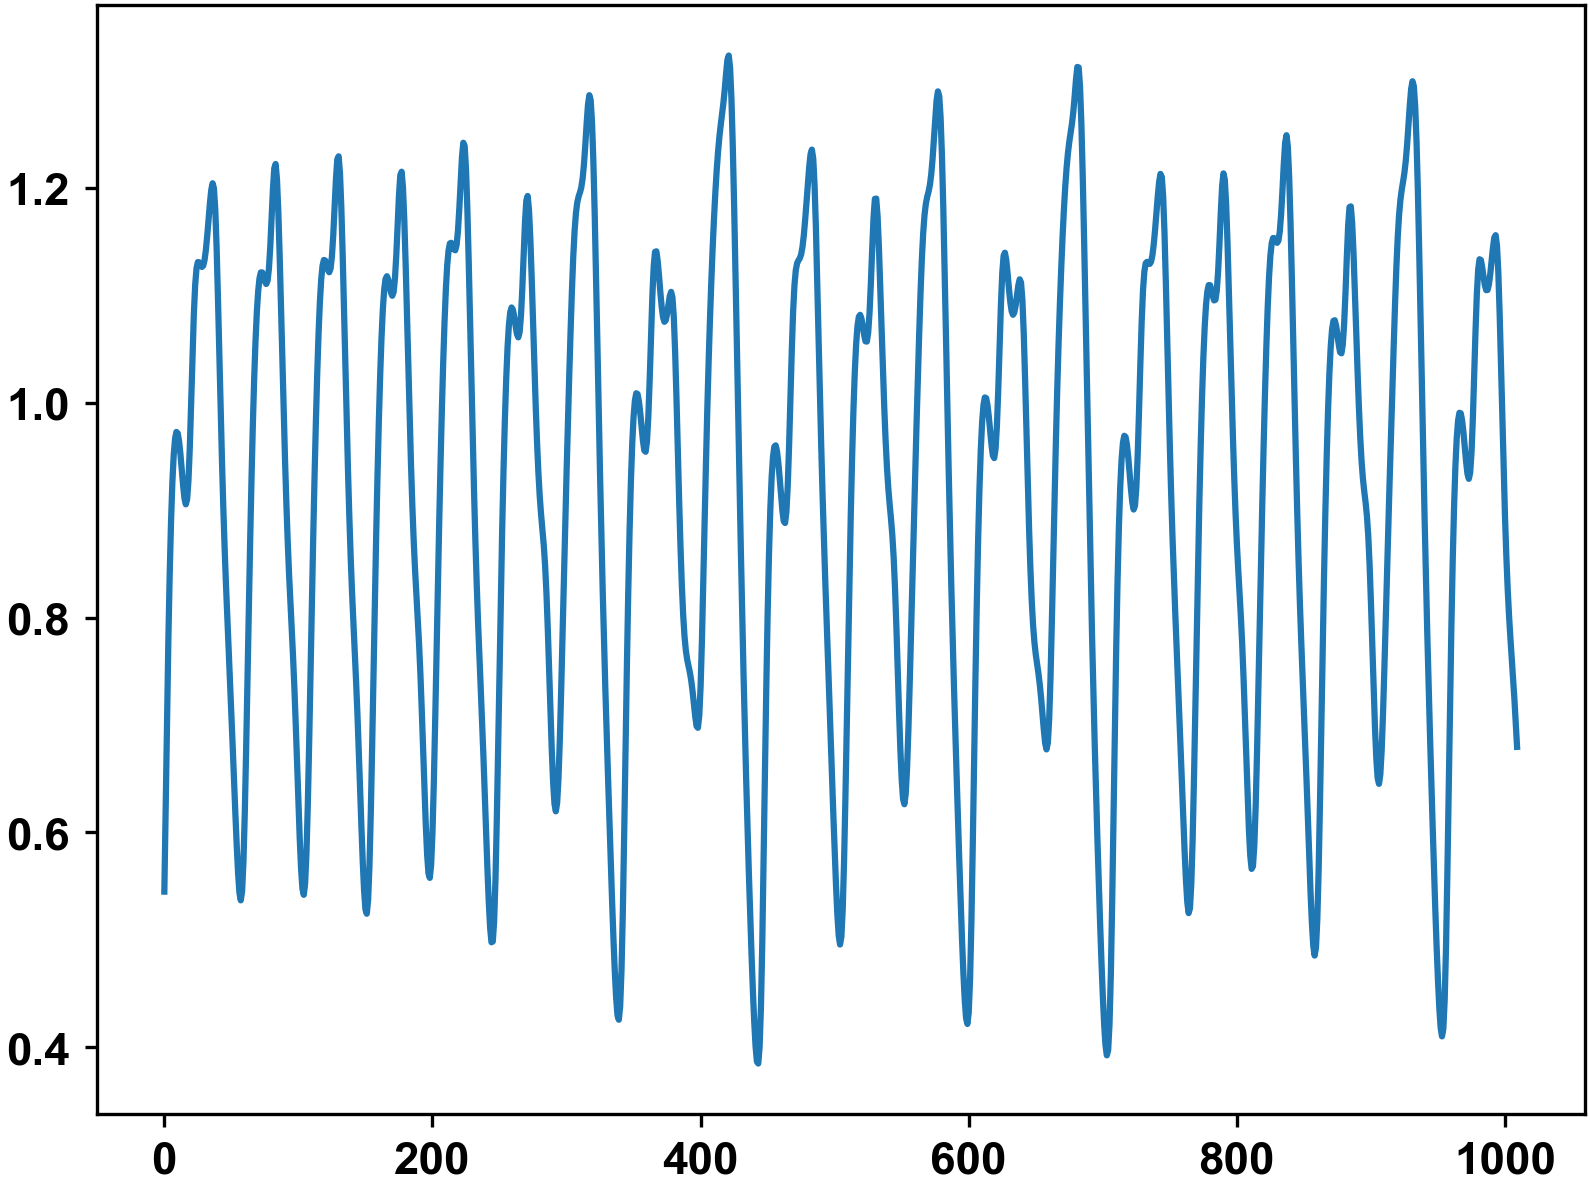

In [3]:
plt.plot(task[:])

In [4]:
N = 4
A, B = make_esn_weights(
    N,
    input_scale=1.0,
    spectral_radius=0.95,
    connectivity=0.1,)

X = esn_dynamics(task, A, B)
# Generate ESN reservoir states for full time series
X.shape

(1010, 4)

In [5]:
Nfading = 100
Ntraining = 700
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau = 10
K = Ntotal-tau

NRMSE: 0.16745676460206788


Text(0.5, 1.0, 'Mackey Glass Prediction by ESN')

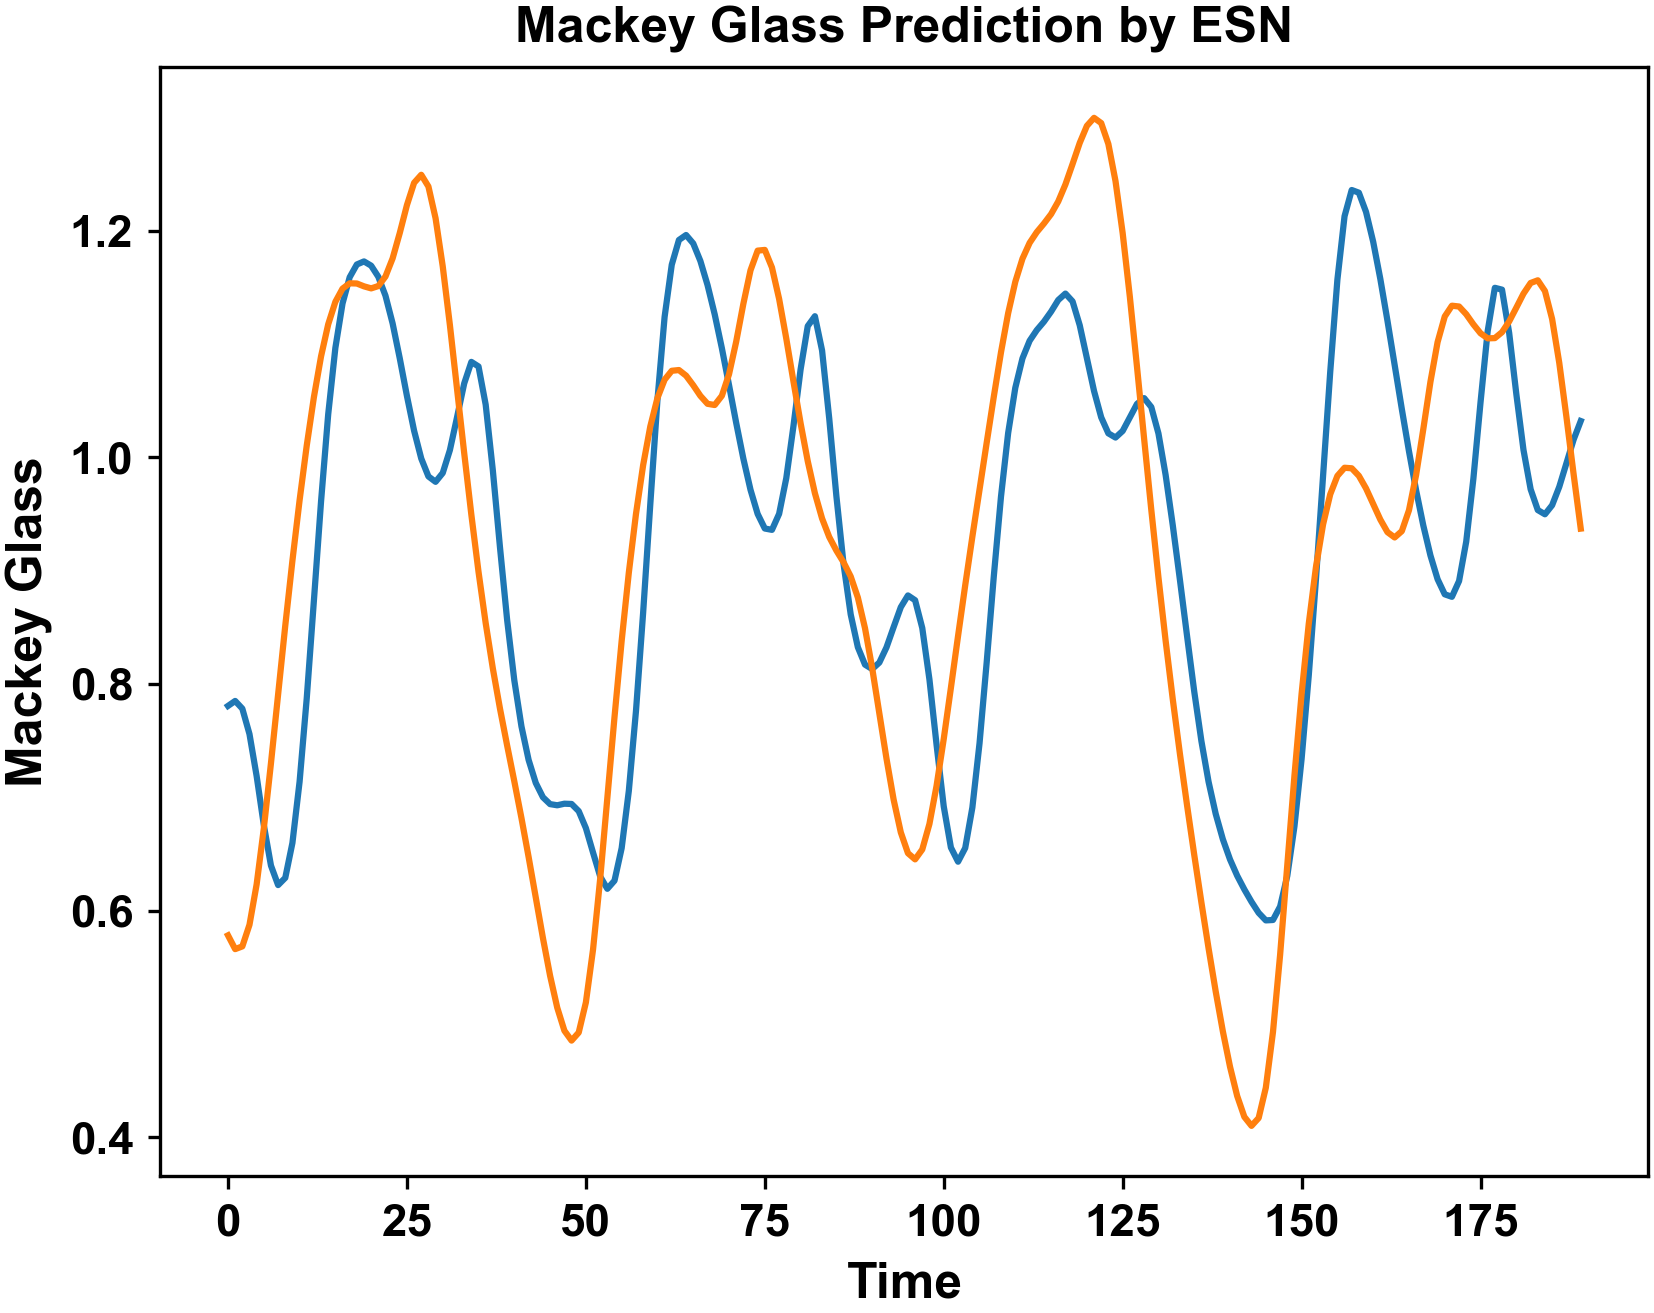

In [6]:
X_features = X[0:K]
X_train = X_features[Nfading : Nfading + Ntraining, :]
X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = task[tau : K + tau]
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Mackey Glass")
plt.title("Mackey Glass Prediction by ESN")

Quantum Performance

In [8]:
df = pd.read_csv("MG_omega0.16_rep3_gammatau1_final.csv")
X = extract_delayed_single_column(df, 'PQ-10', N=4, repeat_steps=3)
X.shape

(1000, 4)

Pick any reservoir here, we show the performance on the mackey glass task.

NRMSE: 0.13580360448725326


Text(0.5, 1.0, 'BTC Prediction by ESN')

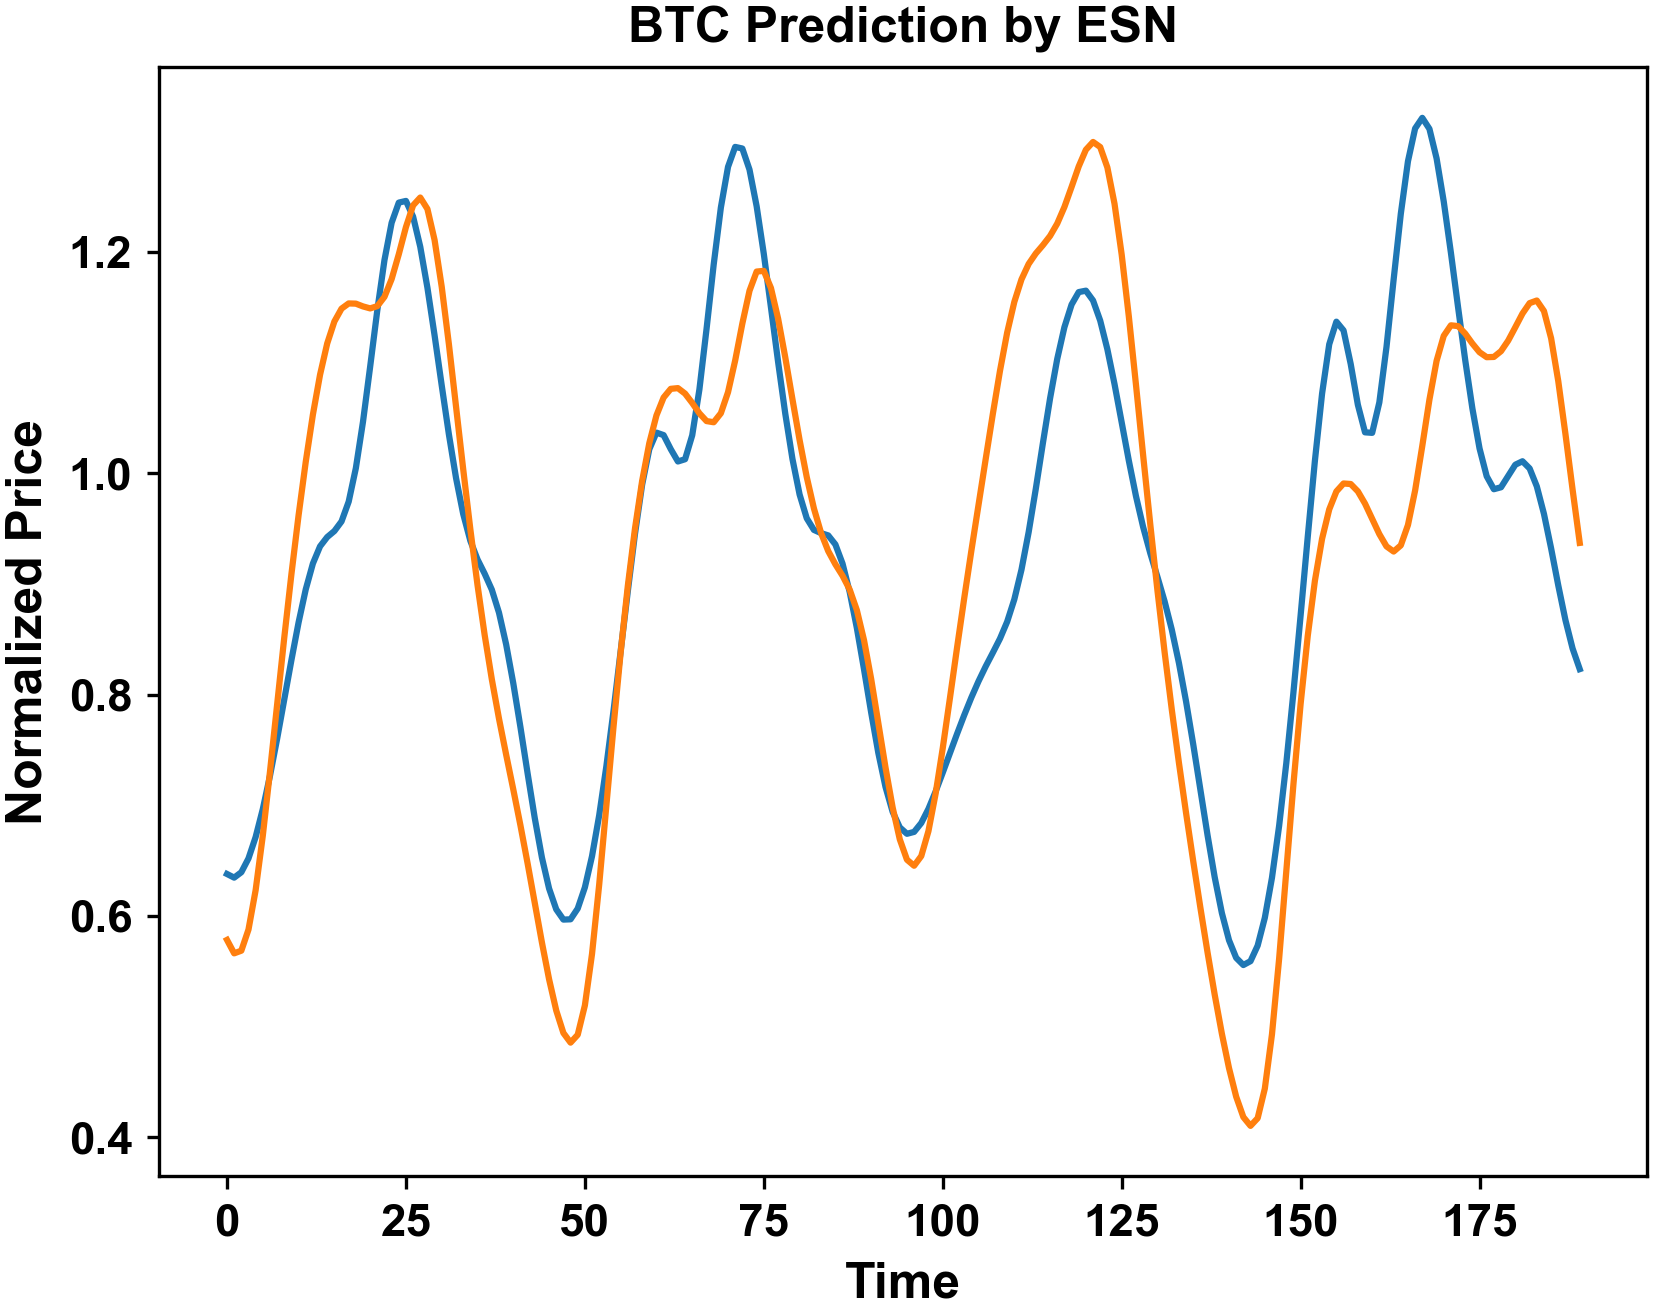

In [10]:
X_features = X[0:K]
X_train = X_features[Nfading : Nfading + Ntraining, :]
X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = task[tau : K + tau]
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.title("BTC Prediction by ESN")

Pick any reservoir here, we show the performance is comparable to ESN

In [12]:
rep = 3
omega = 0.12
name = f'MG_omega{omega}_rep{rep}_gammatau1_final.csv'

In [13]:
nodes = [2,4,6,8,10,12,14,16,18,20,40,50,60,70]
ESN_errors = []
ESN_errors_all = []
Quantum_errors = []
Nfading = 50
Ntraining = 750
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau = 10
K = Ntotal-tau
for r in range(50):
    ESN_errors = []
    for node in nodes: 
        A, B = make_esn_weights(node,input_scale=1.0,spectral_radius=0.95,connectivity=0.1)
        X_ESN= esn_dynamics(task, A, B)
        X_features_ESN = X_ESN[0:K]
        X_train_ESN = X_features_ESN[Nfading : Nfading + Ntraining, :]
        X_test_ESN = X_features_ESN[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
        y_target = task[tau : K + tau]
        y_train = y_target[Nfading : Nfading + Ntraining]
        y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
        W_ESN = fitting_function(X_train_ESN, y_train)
        y_prediction_ESN = predict(X_test_ESN, W_ESN)
        error = nrmse(y_prediction_ESN, y_test)
        ESN_errors.append(error)
    ESN_errors_all.append(ESN_errors)

ESN_errors_all = np.array(ESN_errors_all)
mean_errors = ESN_errors_all.mean(axis=0)
std_errors = ESN_errors_all.std(axis=0)


In [14]:
for node in nodes: 
    df = pd.read_csv(name)
    X_quantum = extract_delayed_single_column(df, 'PQ-10', N=node, repeat_steps=3)
    #X_quantum = add_polynomial_features(X_quantum,nodes=node)
    """cols = np.random.choice(X_quantum.shape[1], size=node, replace=False)
    X_quantum = X_quantum[:, cols]"""
    X_features_quantum = X_quantum[0:K]
    print(X_features_quantum.shape)
    X_train_quantum = X_features_quantum[Nfading : Nfading + Ntraining, :]
    X_test_quantum = X_features_quantum[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
    
    y_target = task[tau : K + tau]
    y_train = y_target[Nfading : Nfading + Ntraining]
    y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
    
    W_quantum = fitting_function(X_train_quantum, y_train)
    y_prediction_quantum = predict(X_test_quantum, W_quantum)
    error = nrmse(y_prediction_quantum, y_test)
    Quantum_errors.append(error)
    

(990, 2)
(990, 4)
(990, 6)
(990, 8)
(990, 10)
(990, 12)
(990, 14)
(990, 16)
(990, 18)
(990, 20)
(990, 40)
(990, 50)
(990, 60)
(990, 70)


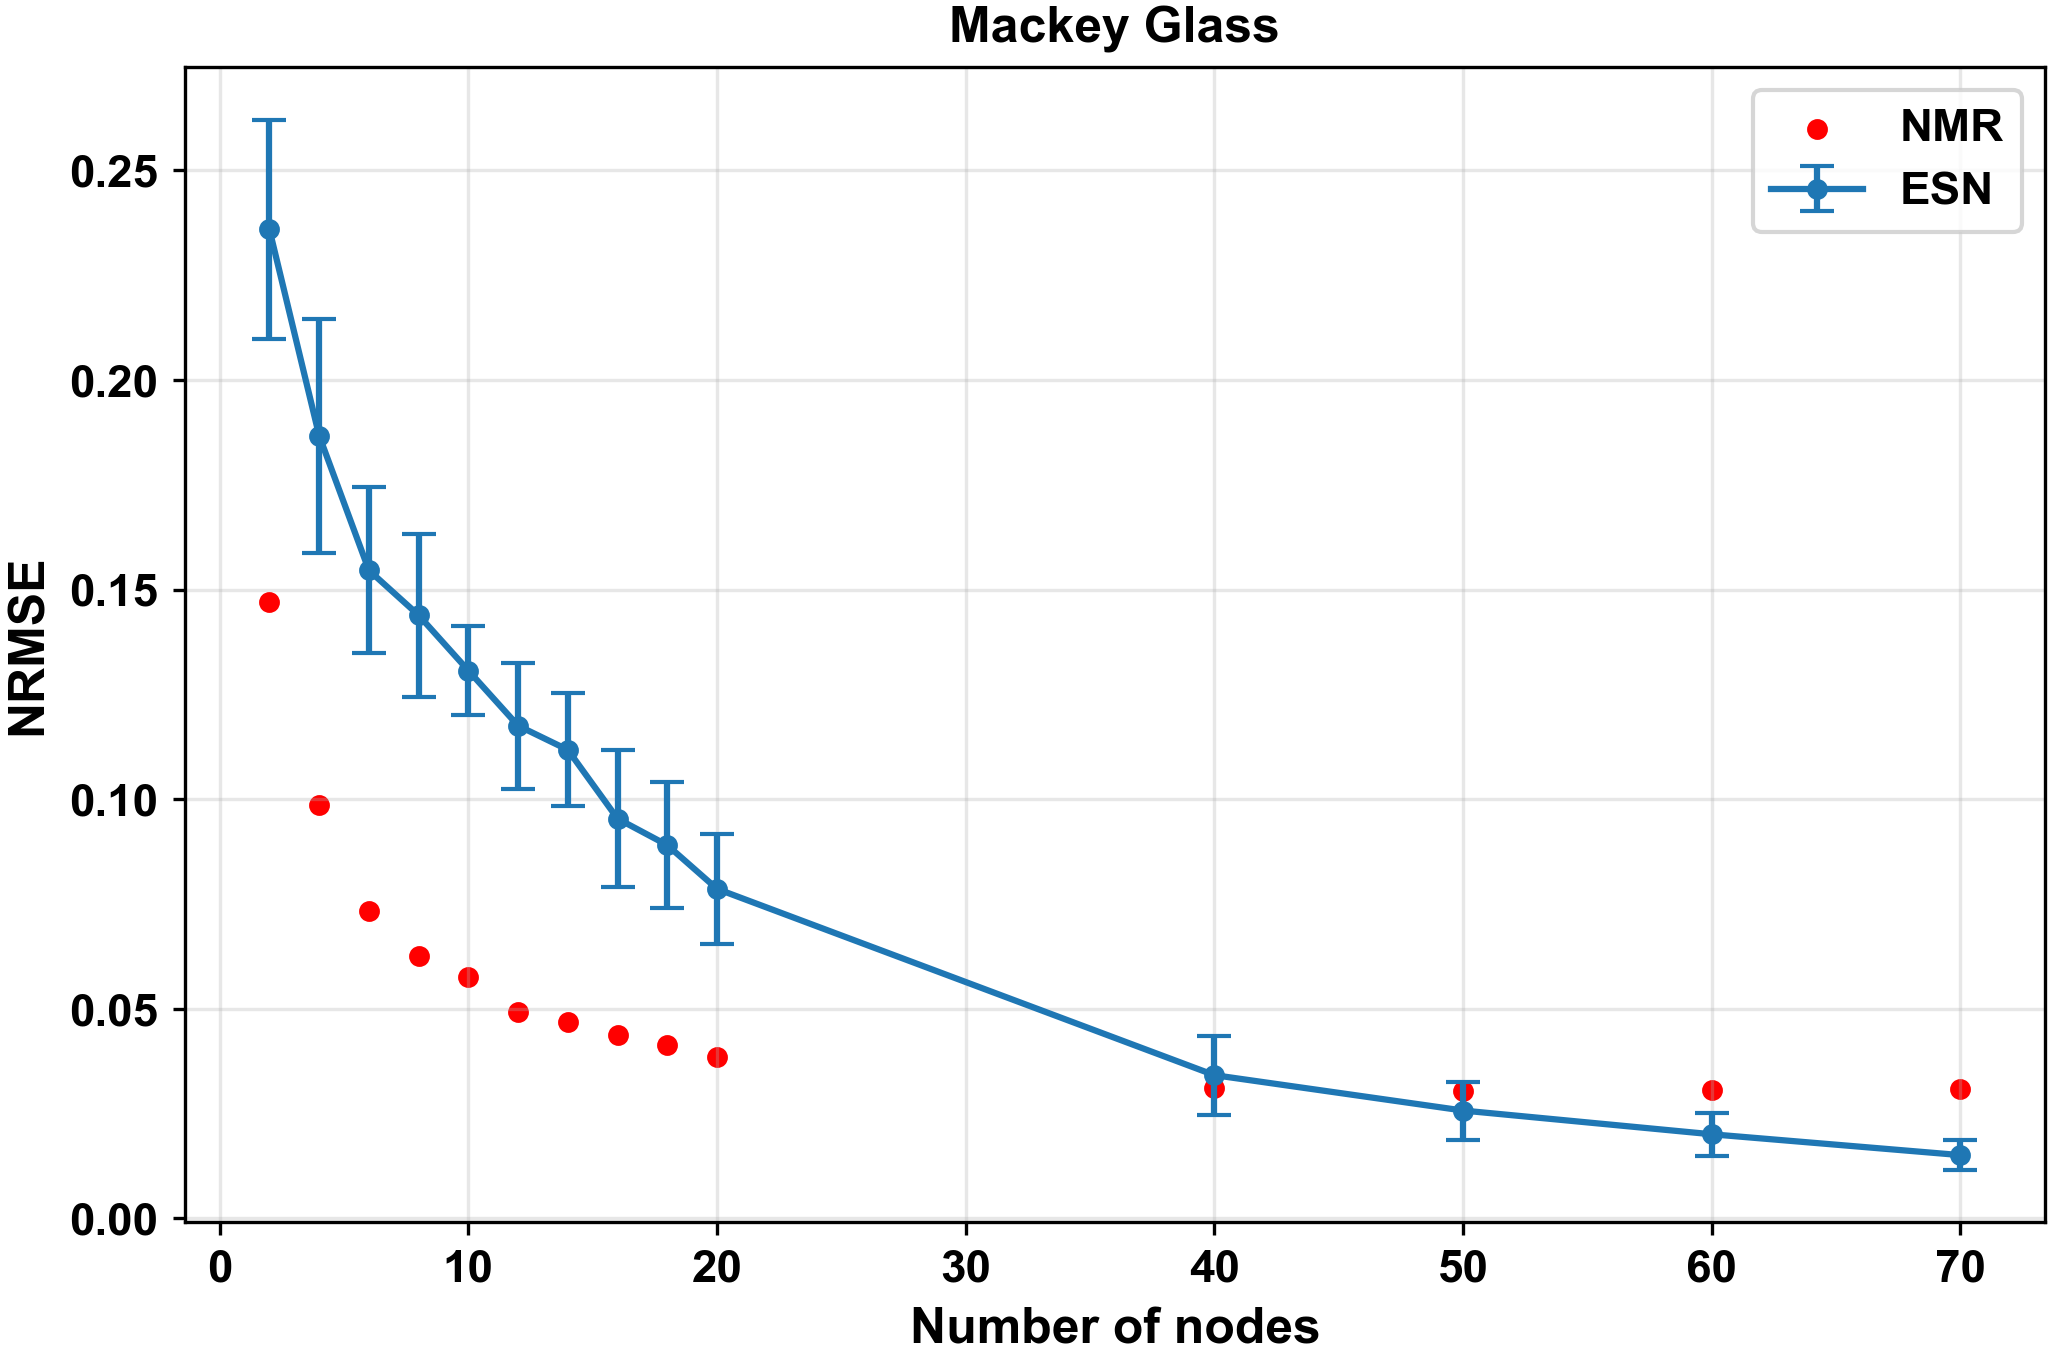

In [15]:
import numpy as np
import matplotlib.pyplot as plt

nodes = np.array(nodes)
plt.figure(figsize=(8, 5))
plt.errorbar(
    nodes,
    mean_errors,
    yerr=std_errors,
    marker='o',
    capsize=4,
    label='ESN'
)

plt.scatter(nodes,Quantum_errors,label='NMR',color='Red')

plt.xlabel("Number of nodes")
plt.ylabel("NRMSE")
plt.title("Mackey Glass")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('mackeyglass.png')
plt.show()

Observe how performance changes by omega

In [17]:
omegas = ["0.08", "0.10", "0.12", "0.14", "0.16"]
NM1_all = []
NM2_all = []
NM3_all = []
NM4_all = []
Cavity_all = []
rep = 3

Nfading = 50
Ntraining = 650
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining

tau = 10
K = Ntotal - tau

# Initialize after determining max_nodes
QuantumNM1_sum = None
QuantumNM2_sum = None
QuantumNM3_sum = None
#QuantumNM4_sum = None
QuantumCavity_sum = None
nodes = None

for omega in omegas:

    # -----------------------------
    # Load data
    # -----------------------------
    df = pd.read_csv(f"MG_omega{omega}_rep{rep}_gammatau1_final.csv")
    X_NM1 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)

    df = pd.read_csv(f"MG_omega{omega}_rep{rep}_gammatau0.5_final.csv")
    X_NM2 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)

    """df = pd.read_csv(f"MG_omega{omega}_rep{rep}_gammatau0.1_final.csv")
    X_NM3 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)"""

    df = pd.read_csv(f"MG_omega{omega}_rep{rep}_gammatau.01_final.csv")
    X_NM4 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)
    
    df = pd.read_csv(f"MackeyGlass_epsilon{omega}.csv")
    X_cavity = df.values

    X_NM1 = X_NM1[:K]
    X_NM2 = X_NM2[:K]
    #X_NM3 = X_NM3[:K]
    X_NM4 = X_NM4[:K]
    X_cavity = X_cavity[:K]

    y_target = task[tau:K+tau]
    y_train = y_target[Nfading:Nfading+Ntraining]
    y_test = y_target[Nfading+Ntraining:Nfading+Ntraining+Ntesting]

    max_nodes = min(X_NM1.shape[1], X_cavity.shape[1])

    QuantumNM1_errors = []
    QuantumNM2_errors = []
    #QuantumNM3_errors = []
    QuantumNM4_errors = []
    QuantumCavity_errors = []
    nodes = list(range(1, max_nodes + 1))

    for n in nodes:

        # NM1
        X_train_NM1 = X_NM1[Nfading:Nfading+Ntraining, -n:]
        X_test_NM1 = X_NM1[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]

        # NM2
        X_train_NM2 = X_NM2[Nfading:Nfading+Ntraining, -n:]
        X_test_NM2 = X_NM2[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]

        # NM3
        #X_train_NM3 = X_NM3[Nfading:Nfading+Ntraining, -n:]
        #X_test_NM3 = X_NM3[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]

        # NM4
        X_train_NM4 = X_NM4[Nfading:Nfading+Ntraining, -n:]
        X_test_NM4 = X_NM4[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]

        # Cavity
        X_train_cavity = X_cavity[Nfading:Nfading+Ntraining, :n]
        X_test_cavity = X_cavity[Nfading+Ntraining:Nfading+Ntraining+Ntesting, :n]

        # Train
        W_NM1 = fitting_function(X_train_NM1, y_train)
        pred_NM1 = predict(X_test_NM1, W_NM1)
        QuantumNM1_errors.append(nrmse(pred_NM1, y_test))

        W_NM2 = fitting_function(X_train_NM2, y_train)
        pred_NM2 = predict(X_test_NM2, W_NM2)
        QuantumNM2_errors.append(nrmse(pred_NM2, y_test))

        #W_NM3 = fitting_function(X_train_NM3, y_train)
        #pred_NM3 = predict(X_test_NM3, W_NM3)
        #QuantumNM3_errors.append(nrmse(pred_NM3, y_test))

        W_NM4 = fitting_function(X_train_NM4, y_train)
        pred_NM4 = predict(X_test_NM4, W_NM4)
        QuantumNM4_errors.append(nrmse(pred_NM4, y_test))

        W_cavity = fitting_function(X_train_cavity, y_train)
        pred_cavity = predict(X_test_cavity, W_cavity)
        QuantumCavity_errors.append(nrmse(pred_cavity, y_test))

    QuantumNM1_errors = np.array(QuantumNM1_errors)
    QuantumNM2_errors = np.array(QuantumNM2_errors)
    #QuantumNM3_errors = np.array(QuantumNM3_errors)
    QuantumNM4_errors = np.array(QuantumNM4_errors)
    QuantumCavity_errors = np.array(QuantumCavity_errors)

    if QuantumNM1_sum is None:
        QuantumNM1_sum = QuantumNM1_errors
        QuantumNM2_sum = QuantumNM2_errors
        #QuantumNM3_sum = QuantumNM3_errors
        QuantumNM4_sum = QuantumNM4_errors
        QuantumCavity_sum = QuantumCavity_errors
    else:
        QuantumNM1_sum += QuantumNM1_errors
        QuantumNM2_sum += QuantumNM2_errors
        #QuantumNM3_sum += QuantumNM3_errors
        QuantumNM4_sum += QuantumNM4_errors
        QuantumCavity_sum += QuantumCavity_errors
        
    NM1_all.append(QuantumNM1_errors)
    NM2_all.append(QuantumNM2_errors)
    #NM3_all.append(QuantumNM3_errors)
    NM4_all.append(QuantumNM4_errors)
    Cavity_all.append(QuantumCavity_errors)
    
# Average
QuantumNM1_avg = QuantumNM1_sum / len(omegas)
QuantumNM2_avg = QuantumNM2_sum / len(omegas)
#QuantumNM3_avg = QuantumNM3_sum / len(omegas)
QuantumNM4_avg = QuantumNM4_sum / len(omegas)
QuantumCavity_avg = QuantumCavity_sum / len(omegas)

NM1_all = np.array(NM1_all)
NM2_all = np.array(NM2_all)
#NM3_all = np.array(NM3_all)
NM4_all = np.array(NM4_all)
Cavity_all = np.array(Cavity_all)

NM1_mean = NM1_all.mean(axis=0)
NM2_mean = NM2_all.mean(axis=0)
#NM3_mean = NM3_all.mean(axis=0)
NM4_mean = NM4_all.mean(axis=0)
Cavity_mean = Cavity_all.mean(axis=0)

NM1_std = NM1_all.std(axis=0)
NM2_std = NM2_all.std(axis=0)
#NM3_std = NM3_all.std(axis=0)
NM4_std = NM4_all.std(axis=0)
Cavity_std = Cavity_all.std(axis=0)

NM1_sem = NM1_std / np.sqrt(len(omegas))
NM2_sem = NM2_std / np.sqrt(len(omegas))
#NM3_sem = NM3_std / np.sqrt(len(omegas))
NM4_sem = NM4_std / np.sqrt(len(omegas))
Cavity_sem = Cavity_std / np.sqrt(len(omegas))

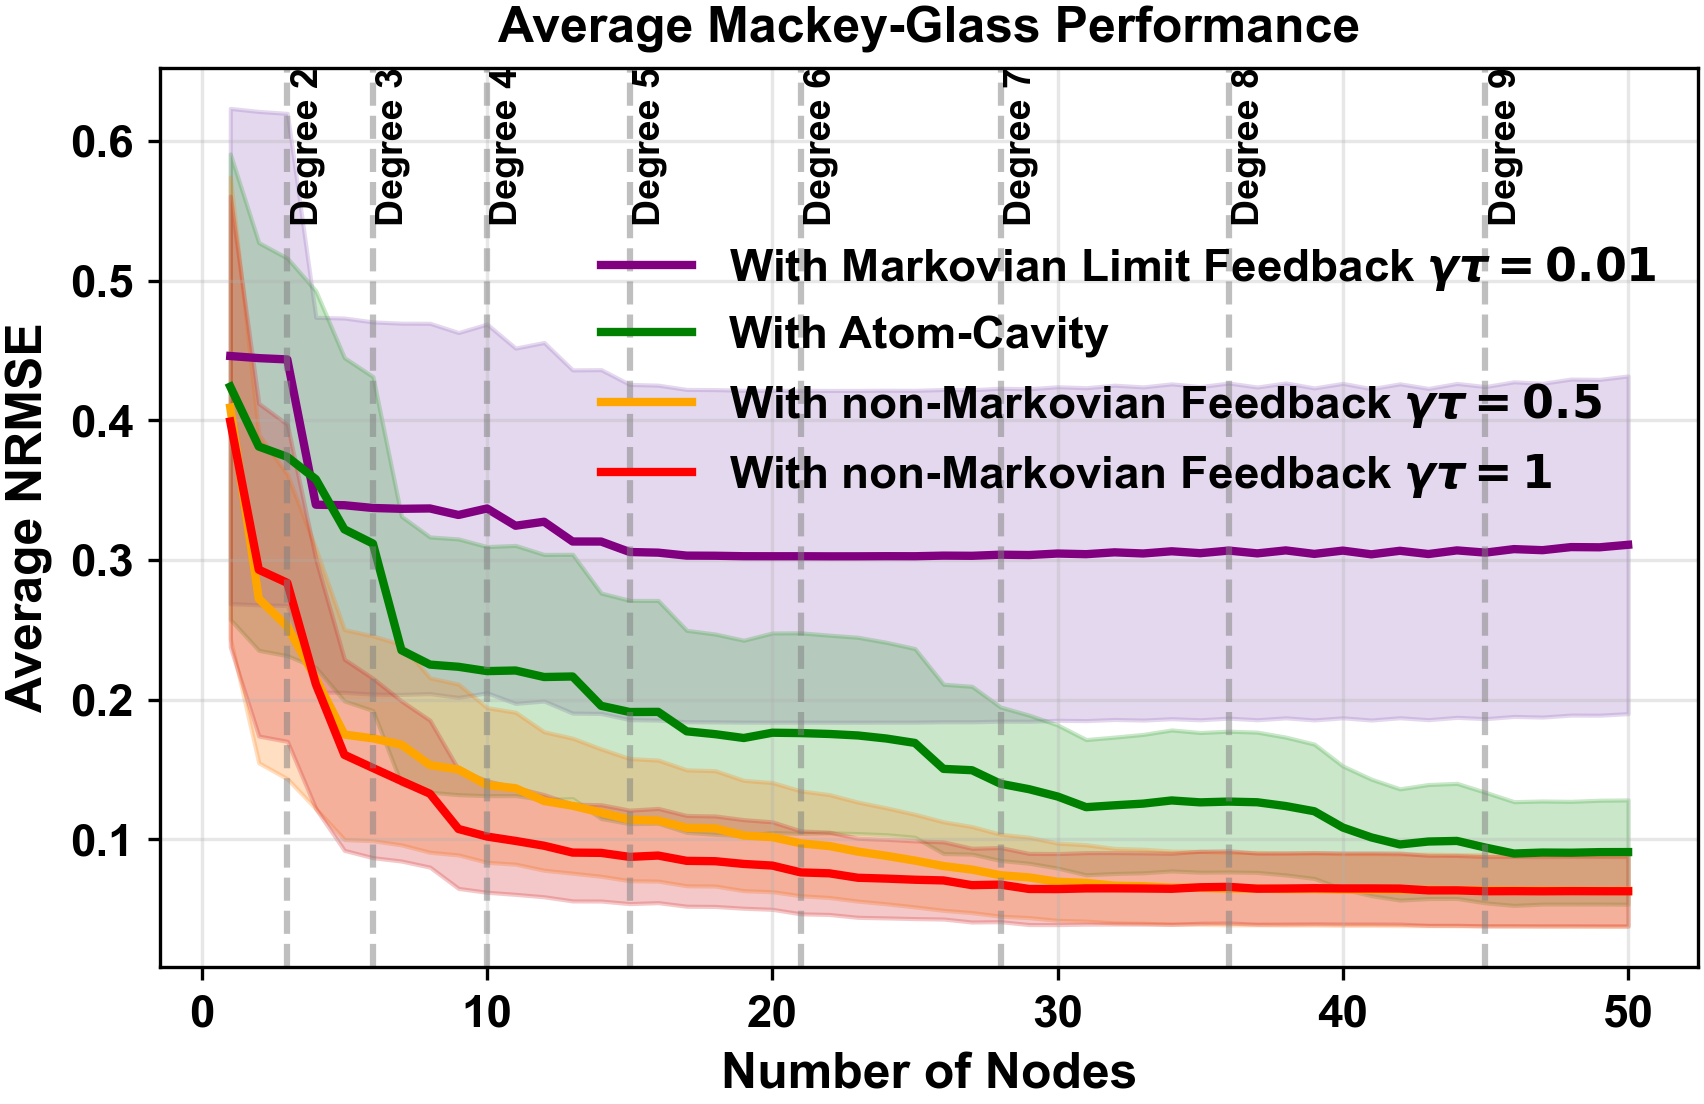

In [18]:
degree_starts = {
    "Degree 2": 3,
    "Degree 3": 6,
    "Degree 4": 10,
    "Degree 5": 15,
    "Degree 6": 21,
    "Degree 7": 28,
    "Degree 8": 36,
    "Degree 9": 45,
}

plt.figure(figsize=(6,4))

plt.plot(nodes, NM4_mean, color='purple', lw=2,
         label='With Markovian Limit Feedback $\\gamma\\tau=0.01$')
plt.fill_between(nodes,
                 NM4_mean - NM4_sem,
                 NM4_mean + NM4_sem,
                 color='tab:purple',
                 alpha=0.25)


"""plt.plot(nodes, NM3_mean, color='blue', lw=2,
         label='With non-Markovian feedback ($\\gamma\\tau=.1$)')
plt.fill_between(nodes,
                 NM3_mean - NM3_sem,
                 NM3_mean + NM3_sem,
                 color='tab:blue',
                 alpha=0.25)"""

plt.plot(nodes, Cavity_mean, color='green', lw=2,
         label='With Atom-Cavity')
plt.fill_between(nodes,
                 Cavity_mean - Cavity_sem,
                 Cavity_mean + Cavity_sem,
                 color='tab:green',
                 alpha=0.25)

plt.plot(nodes, NM2_mean, color='orange', lw=2,
         label='With non-Markovian Feedback $\\gamma\\tau=0.5$')
plt.fill_between(nodes,
                 NM2_mean - NM2_sem,
                 NM2_mean + NM2_sem,
                 color='tab:orange',
                 alpha=0.25)

 
# Mean ± SEM
plt.plot(nodes, NM1_mean, color='red', lw=2,
         label='With non-Markovian Feedback $\\gamma\\tau=1$')
plt.fill_between(nodes,
                 NM1_mean - NM1_sem,
                 NM1_mean + NM1_sem,
                 color='tab:red',
                 alpha=0.25)


plt.xlabel("Number of Nodes")
plt.ylabel("Average NRMSE")
plt.title("Average Mackey-Glass Performance")

for label, x in degree_starts.items():
    plt.axvline(x=x, color='gray', linestyle='--', alpha=0.5)
    plt.text(x+.1,
             plt.ylim()[1],
             label,
             rotation=90,
             va='top',
             fontsize=9)
    
plt.grid(alpha=0.3)
plt.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1, 0.85))
plt.tight_layout()
plt.savefig("Average_MackeyGlass_Nodes.png", dpi=300)
plt.show()

In [19]:
############## NARMA10
task, inputs = narma(
    Npoints=1000,
    order=10,
    delay=10,
    seed=1234
)
inputs

array([3.19814499e-01, 4.40391348e-01, 5.29658459e-02, 8.25654160e-02,
       2.61458150e-02, 4.54574482e-01, 2.48401082e-01, 1.55235581e-01,
       8.33766975e-02, 4.86245809e-01, 2.97793728e-01, 3.06084472e-01,
       3.41960310e-01, 3.53617478e-02, 3.78780521e-01, 1.56454289e-01,
       3.15500749e-01, 5.88213990e-02, 3.84338555e-01, 4.82213612e-01,
       2.24607274e-01, 3.14712066e-01, 7.89214493e-02, 4.15893923e-01,
       2.57483717e-01, 2.85667884e-01, 1.14022319e-01, 1.25364745e-01,
       6.46068941e-02, 2.66477619e-01, 3.27043567e-01, 2.70480458e-01,
       3.43731415e-01, 4.29014514e-01, 3.42848704e-01, 2.55012131e-01,
       4.00445052e-01, 2.77937756e-03, 1.50092726e-01, 4.75997301e-01,
       2.94533592e-01, 4.11338026e-01, 2.25518936e-01, 4.84331452e-01,
       4.29312949e-01, 9.29779550e-02, 1.23329126e-01, 1.63762394e-01,
       3.14961588e-01, 1.73439691e-01, 1.75129969e-01, 6.51267681e-02,
       1.32787668e-01, 7.50306773e-02, 2.09202679e-01, 2.98227650e-01,
      

In [20]:
omegas = ["0.08", "0.10", "0.12", "0.14", "0.16"]
rep = 3

Nfading = 50
Ntraining = 650
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining

NM1_all = []
NM2_all = []
NM3_all = []
NM4_all = []
Cavity_all = []

for omega in omegas:

    # -----------------------------
    # Load data
    # -----------------------------
    df = pd.read_csv(f"NM_omega{omega}_rep{rep}_gammatau1_final.csv")
    X_NM1 = extract_delayed_single_column(df, "PQ-1", N=50, repeat_steps=rep)

    df = pd.read_csv(f"NM_omega{omega}_rep{rep}_gammatau0.5_final.csv")
    X_NM2 = extract_delayed_single_column(df, "PQ-1", N=50, repeat_steps=rep)

    """df = pd.read_csv(f"NM_omega{omega}_rep{rep}_gammatau0.1_final.csv")
    X_NM3 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)"""

    df = pd.read_csv(f"NM_omega{omega}_rep{rep}_gammatau0.01_final.csv")
    X_NM4 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)

    df = pd.read_csv(f"NM10_epsilon{omega}.csv")
    X_cavity = df.values

    y_target = task
    y_train = y_target[Nfading:Nfading+Ntraining]
    y_test  = y_target[Nfading+Ntraining:Nfading+Ntraining+Ntesting]

    max_nodes = min(
        X_NM1.shape[1],
        X_NM2.shape[1],
        #X_NM3.shape[1],
        X_cavity.shape[1]
    )

    nodes = np.arange(1, max_nodes+1)

    NM1_errors = []
    NM2_errors = []
    #NM3_errors = []
    NM4_errors = []
    Cavity_errors = []

    for n in nodes:

        # -----------------------------
        # NM1 (τ=10)
        # -----------------------------
        X_train = X_NM1[Nfading:Nfading+Ntraining,-n:]
        X_test  = X_NM1[Nfading+Ntraining:Nfading+Ntraining+Ntesting,-n:]

        W = fitting_function(X_train,y_train)
        pred = predict(X_test,W)
        NM1_errors.append(nrmse(pred,y_test))

        # -----------------------------
        # NM2 (τ=1)
        # -----------------------------
        X_train = X_NM2[Nfading:Nfading+Ntraining,-n:]
        X_test  = X_NM2[Nfading+Ntraining:Nfading+Ntraining+Ntesting,-n:]

        W = fitting_function(X_train,y_train)
        pred = predict(X_test,W)
        NM2_errors.append(nrmse(pred,y_test))

        # -----------------------------
        # NM3 (τ=0)
        # -----------------------------
        """X_train = X_NM3[Nfading:Nfading+Ntraining,-n:]
        X_test  = X_NM3[Nfading+Ntraining:Nfading+Ntraining+Ntesting,-n:]

        W = fitting_function(X_train,y_train)
        pred = predict(X_test,W)
        NM3_errors.append(nrmse(pred,y_test))"""

        # -----------------------------
        # NM4
        # -----------------------------
        X_train = X_NM4[Nfading:Nfading+Ntraining,-n:]
        X_test  = X_NM4[Nfading+Ntraining:Nfading+Ntraining+Ntesting,-n:]

        W = fitting_function(X_train,y_train)
        pred = predict(X_test,W)
        NM4_errors.append(nrmse(pred,y_test))

        # -----------------------------
        # Cavity
        # -----------------------------
        X_train = X_cavity[Nfading:Nfading+Ntraining,:n]
        X_test  = X_cavity[Nfading+Ntraining:Nfading+Ntraining+Ntesting,:n]

        W = fitting_function(X_train,y_train)
        pred = predict(X_test,W)
        Cavity_errors.append(nrmse(pred,y_test))

    NM1_all.append(NM1_errors)
    NM2_all.append(NM2_errors)
    #NM3_all.append(NM3_errors)
    NM4_all.append(NM4_errors)
    Cavity_all.append(Cavity_errors)

NM1_all = np.array(NM1_all)
NM2_all = np.array(NM2_all)
#NM3_all = np.array(NM3_all)
NM4_all = np.array(NM4_all)
Cavity_all = np.array(Cavity_all)

NM1_mean = NM1_all.mean(axis=0)
NM2_mean = NM2_all.mean(axis=0)
#NM3_mean = NM3_all.mean(axis=0)
NM4_mean = NM4_all.mean(axis=0)
Cavity_mean = Cavity_all.mean(axis=0)

NM1_sem = NM1_all.std(axis=0)/np.sqrt(len(omegas))
NM2_sem = NM2_all.std(axis=0)/np.sqrt(len(omegas))
#NM3_sem = NM3_all.std(axis=0)/np.sqrt(len(omegas))
NM4_sem = NM4_all.std(axis=0)/np.sqrt(len(omegas))
Cavity_sem = Cavity_all.std(axis=0)/np.sqrt(len(omegas))

<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Phi Hung Nguyen\AppData\Local\Temp\ipykernel_324\4103162083.py:11: SyntaxWarning: invalid escape sequence '\g'
  """plt.plot(nodes, NM3_mean, color='blue', lw=3,


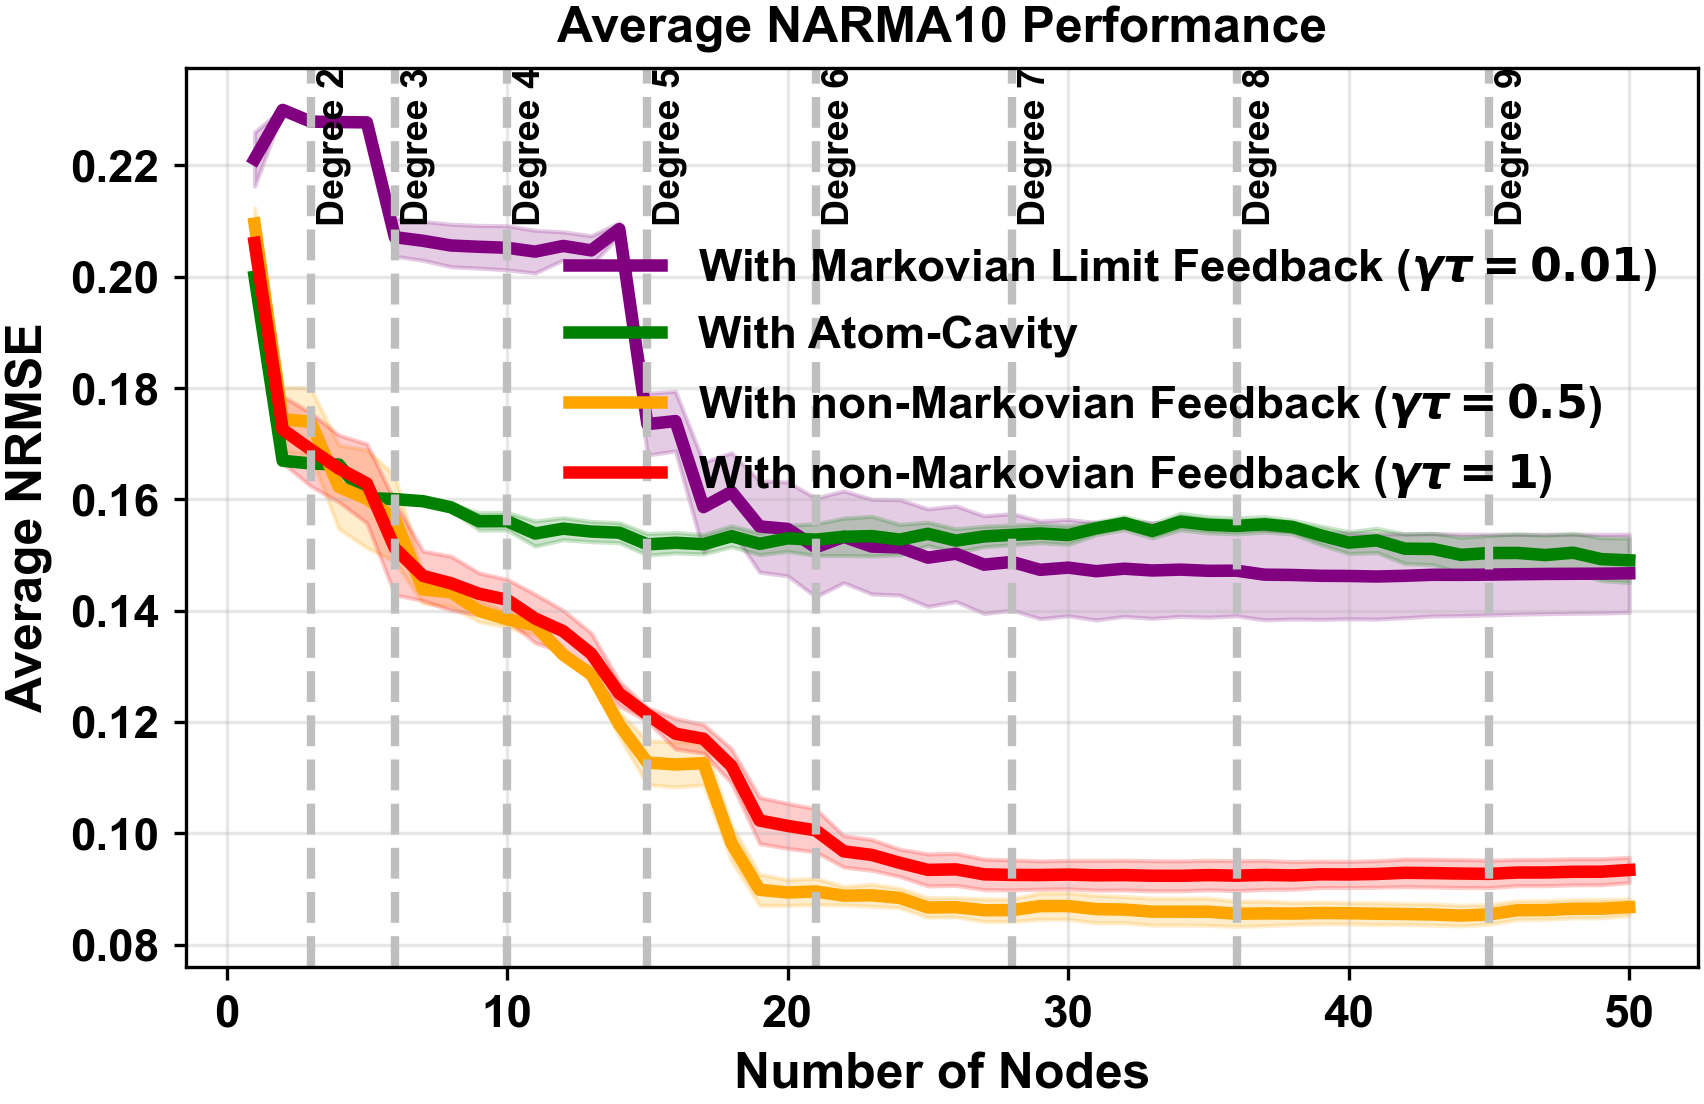

In [21]:
plt.figure(figsize=(6,4))

plt.plot(nodes, NM4_mean, color='purple', lw=3,
         label=r'With Markovian Limit Feedback ($\gamma\tau=0.01$)')
plt.fill_between(nodes,
                 NM4_mean-NM4_sem,
                 NM4_mean+NM4_sem,
                 color='purple',
                 alpha=0.20)

"""plt.plot(nodes, NM3_mean, color='blue', lw=3,
         label=r'With non-Markovian feedback ($\gamma\tau=.1$)')
plt.fill_between(nodes,
                 NM3_mean-NM3_sem,
                 NM3_mean+NM3_sem,
                 color='blue',
                 alpha=0.20)"""



plt.plot(nodes, Cavity_mean, color='green', lw=3,
         label='With Atom-Cavity')
plt.fill_between(nodes,
                 Cavity_mean-Cavity_sem,
                 Cavity_mean+Cavity_sem,
                 color='green',
                 alpha=0.20)

plt.plot(nodes, NM2_mean, color='orange', lw=3,
         label=r'With non-Markovian Feedback ($\gamma\tau=0.5$)')
plt.fill_between(nodes,
                 NM2_mean-NM2_sem,
                 NM2_mean+NM2_sem,
                 color='orange',
                 alpha=0.20)

plt.plot(nodes, NM1_mean, color='red', lw=3,
         label=r'With non-Markovian Feedback ($\gamma\tau=1$)')
plt.fill_between(nodes,
                 NM1_mean-NM1_sem,
                 NM1_mean+NM1_sem,
                 color='red',
                 alpha=0.20)


degree_starts = {
    "Degree 2": 3,
    "Degree 3": 6,
    "Degree 4": 10,
    "Degree 5": 15,
    "Degree 6": 21,
    "Degree 7": 28,
    "Degree 8": 36,
    "Degree 9": 45,
}

for label, x in degree_starts.items():
    plt.axvline(x, color='0.75', ls='--', lw=2)
    plt.text(x+0.2,
             plt.ylim()[1],
             label,
             rotation=90,
             va='top',
             fontsize=9)

plt.xlabel("Number of Nodes")
plt.ylabel("Average NRMSE")
plt.title("Average NARMA10 Performance")

plt.grid(alpha=0.3)
plt.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1, 0.85))
plt.tight_layout()
plt.savefig("Average_NARMA10_Nodes.png", dpi=300)
plt.show()